## Importando Bibliotecas

In [3]:
# Utilizando pandas para manipulação de dados em tabelas
import pandas as pd

# Utilizando numpy para operações matemáticas e arrays
import numpy as np

# Utilizando matplotlib para criação de graficos
import matplotlib.pyplot as plt

# Utilizando seaborn para visualização estatística de dados
import seaborn as sbn

# Utilizando random para criação de números aleatórios
import random

# Utilizando as classes datetime e timedelta para manipulação de datas e tempo
from datetime import datetime, timedelta

# Comando para exibir os gráficos diretamente no notebook
%matplotlib inline

## Função para gerar dados aleatórios

In [8]:
def dados_aleatorios(num_dados = 600): 
    """
     Gera um dataframe do Pandas com dados de vendas fictícios
    """

    print(f"\nIniciando a criação de {num_dados} registros de vendas...")

    #Dicionario com produtos, categorias e preços
    produtos = {
        'Camiseta': {'categoria':'Roupas', 'preco': 150.00},
        'Tênis': {'categoria':'Calçados', 'preco': 650.00},
        'Boné': {'categoria':'Acessórios', 'preco': 100.00},
        'Calça': {'categoria':'Roupas', 'preco': 360.00},
        'Chinelo': {'categoria':'Calçados', 'preco': 80.99},
        'Mochila': {'categoria':'Acessórios', 'preco': 120.50},
        'Shorts': {'categoria':'Roupas', 'preco': 210.00},
    }

    # Lista com nome dos produtos
    lista_produtos = list(produtos.keys())

    #Dicionario com cidades e estados
    cidades_estados = {
        'São Paulo': 'SP',
        'Rio de Janeiro': 'RJ',
        'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS',
        'Salvador': 'BA',
    }
    
    # Lista com nome das cidades
    lista_cidades = list(cidades_estados.keys())

    # Lista para armazenar os registros de vendas
    lista_vendas = []

    # Define a data inicial dos pedidos
    data = datetime(2026,4,8)

    # Loop para gerar os registros de vendas
    for i in range(num_dados):
        
        # Seleciona aleatoriamente um produto
        produto_nome = random.choice(lista_produtos)

        # Seleciona aleatoriamente uma cidade
        cidade = random.choice(lista_cidades)

        # Gera uma quantidade de produtos vendida entre 1 e 7
        quantidade = np.random.randint(1, 8)

        # Calcula a data do pedido a partir da data inicial
        data_pedido = data + timedelta(days = int(i/5), hours = random.randint(0, 23))

        # Se o produto for Mouse ou Teclado, aplica desconto aleatório de até 10%
        if produto_nome in ['Camiseta', 'Boné']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']

        # Adiciona um registro de venda à lista
        lista_vendas.append({
            'ID_Pedido': 100 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })
    
    # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    # Retorna os dados no formato de DataFrame
    return pd.DataFrame(lista_vendas)
    

## Explorando os Dados

In [9]:
df_vendas = dados_aleatorios(400)


Iniciando a criação de 400 registros de vendas...
Geração de dados concluída.



In [10]:
# Exibi as 5 primeiras linhas do dataframe
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,100,2026-04-08 11:00:00,Chinelo,Calçados,80.99,2,138,Rio de Janeiro,RJ
1,101,2026-04-08 18:00:00,Boné,Acessórios,95.82,6,136,Belo Horizonte,MG
2,102,2026-04-08 10:00:00,Chinelo,Calçados,80.99,6,124,Rio de Janeiro,RJ
3,103,2026-04-08 04:00:00,Shorts,Roupas,210.00,3,107,Salvador,BA
4,104,2026-04-08 00:00:00,Tênis,Calçados,650.00,1,103,Rio de Janeiro,RJ


In [11]:
# Exibi as 5 últimas linhas do dataframe
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
395,495,2026-06-26 13:00:00,Tênis,Calçados,650.00,1,143,Rio de Janeiro,RJ
396,496,2026-06-26 20:00:00,Mochila,Acessórios,120.50,4,108,Rio de Janeiro,RJ
397,497,2026-06-26 07:00:00,Chinelo,Calçados,80.99,1,113,Salvador,BA
398,498,2026-06-26 03:00:00,Shorts,Roupas,210.00,3,111,Salvador,BA
399,499,2026-06-26 06:00:00,Tênis,Calçados,650.00,2,132,São Paulo,SP


In [12]:
# Criando uma coluna de Faturamento
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [13]:
#Convertendo a coluna Data Pedido para datetime
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

## Análise - Faturamento por Categoria

In [21]:
faturamento_categoria = (
    df_vendas.groupby('Categoria')['Faturamento']
    .sum()
    .sort_values(ascending=False)
)

faturamento_formatado = faturamento_categoria.apply(
    lambda x: f"R$ {x:,.2f}"
)

print(faturamento_formatado)

Categoria
Calçados      R$ 162,119.88
Roupas        R$ 151,499.86
Acessórios     R$ 46,225.52
Name: Faturamento, dtype: object


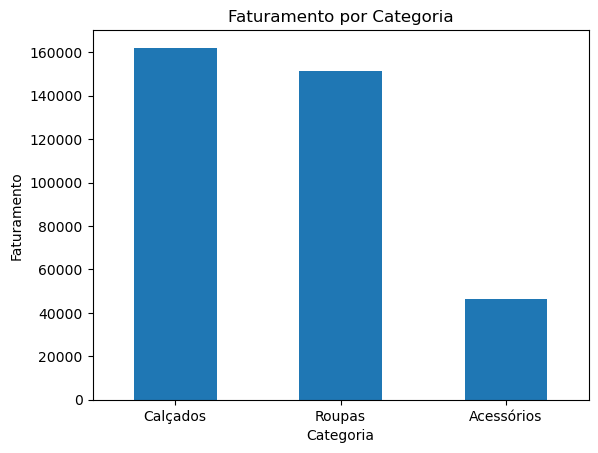

In [23]:

# Garantir que está ordenado
faturamento_categoria = faturamento_categoria.sort_values(ascending=False)

# Criar gráfico
plt.figure()
faturamento_categoria.plot(kind='bar')

# Títulos
plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')

# Melhorar visual
plt.xticks(rotation=0)

plt.show()

## Análise - Top 5 produtos mais vendidos(Quantidade) 

In [34]:
top_produtos = (
    df_vendas.groupby('Nome_Produto')['Quantidade']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_produtos)

Nome_Produto
Shorts      277
Boné        237
Camiseta    223
Tênis       223
Chinelo     212
Name: Quantidade, dtype: int64


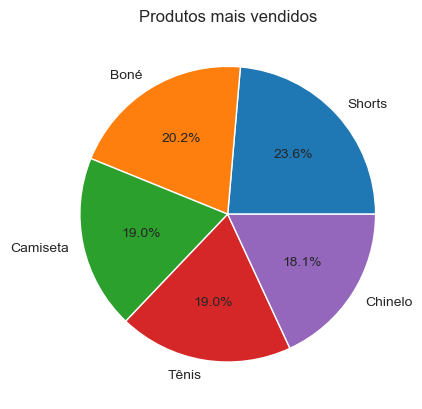

In [35]:
plt.figure()

top_produtos.plot(kind='pie', autopct='%1.1f%%')

plt.title('Produtos mais vendidos')
plt.ylabel('')  # remove texto lateral

plt.show()

## Análise - Top 5 produtos mais vendidos(Faturamento) 

In [36]:
top_produtosF = (
    df_vendas.groupby('Nome_Produto')['Faturamento']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

faturamento_formatado2 = top_produtosF.apply(
    lambda x: f"R$ {x:,.2f}"
)    


print(faturamento_formatado2)

Nome_Produto
Tênis       R$ 144,950.00
Calça        R$ 61,560.00
Shorts       R$ 58,170.00
Camiseta     R$ 31,769.86
Mochila      R$ 23,618.00
Name: Faturamento, dtype: object


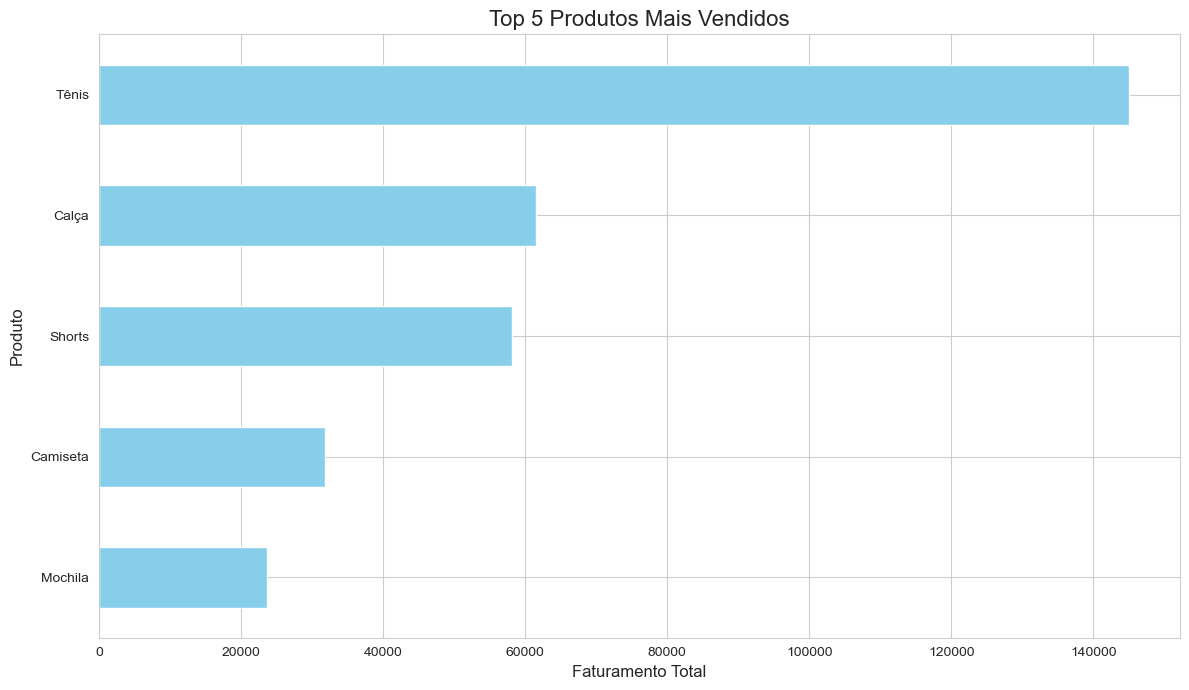

In [37]:
sbn.set_style("whitegrid")

# Cria a figura e os eixos
plt.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_produtosF.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

# Adiciona títulos e labels
plt.title('Top 5 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Faturamento Total', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()